In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

plt.show()


In [2]:
df = pd.read_csv("../data/processed/hotel_bookings_clean.csv")
df.head()


,booking_id,hotel_type,lead_time,arrival_month,arrival_weekday,stays_in_weekend_nights,stays_in_week_nights,adults,children,customer_type,adr,is_canceled,total_nights
0,1,Resort Hotel,50,May,Sunday,3,1,3,NaN,Contract,364.83,0,4
1,2,City Hotel,70,February,Thursday,1,1,1,1.0,Contract,169.58,1,2
2,3,Resort Hotel,47,March,Friday,0,2,2,0.0,Transient-Party,355.68,1,2
3,4,Resort Hotel,18,April,Saturday,1,8,3,1.0,Transient-Party,483.12,1,9
4,5,Resort Hotel,261,June,Wednesday,0,6,3,1.0,Group,272.23,0,6


In [3]:
monthly_demand = df.groupby("arrival_month").size().reset_index(name="bookings")
monthly_demand


,arrival_month,bookings
0,April,838
1,August,838
2,December,819
3,February,871
4,January,868
5,July,823
6,June,870
7,March,846
8,May,801
9,November,778


In [4]:
month_mapping = {
    "January":1, "February":2, "March":3, "April":4,
    "May":5, "June":6, "July":7, "August":8,
    "September":9, "October":10, "November":11, "December":12
}

monthly_demand['month_num'] = monthly_demand['arrival_month'].map(month_mapping)
monthly_demand


,arrival_month,bookings,month_num
0,April,838,4
1,August,838,8
2,December,819,12
3,February,871,2
4,January,868,1
5,July,823,7
6,June,870,6
7,March,846,3
8,May,801,5
9,November,778,11


In [5]:
X = monthly_demand[['month_num']]
y = monthly_demand['bookings']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, r2


(21.64757709251103, 0.1845794532865832)

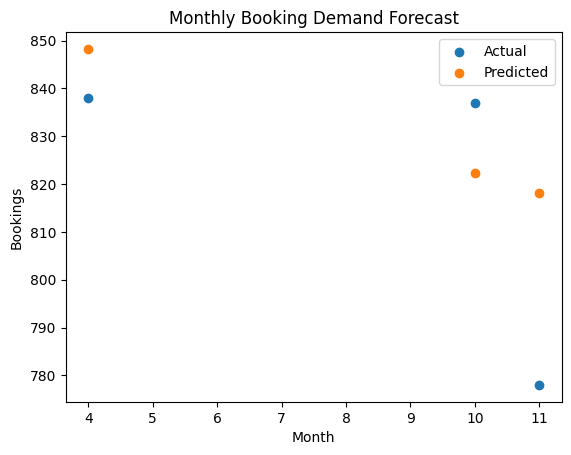

In [8]:
plt.scatter(X_test, y_test, label="Actual")
plt.scatter(X_test, y_pred, label="Predicted")
plt.xlabel("Month")
plt.ylabel("Bookings")
plt.title("Monthly Booking Demand Forecast")
plt.legend()
plt.show()


In [9]:
import joblib
joblib.dump(model, "../models/demand_forecast_model.pkl")


['../models/demand_forecast_model.pkl']